# import package

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import sys


In [3]:
sys.path.append('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal')

import GeoConformalSpatialRegression

In [4]:
import GeoSIMCPzhao

In [5]:
!pip install xgboost geopandas geoplot contextily

In [6]:
import xgboost as xgb
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geoplot as gplt
import geoplot.crs as gcrs
from sklearn.model_selection import train_test_split
import contextily as cx


# Load data

In [7]:
# # # ## housing price

data = pd.read_csv('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity//data/seattle_sample_3k.csv')
data = gpd.GeoDataFrame(data, crs="EPSG:32610", geometry=gpd.points_from_xy(x=data.UTM_X, y=data.UTM_Y))
data = data.to_crs(4326)

data['lat'] = data['geometry'].get_coordinates()['x']
data['lon'] = data['geometry'].get_coordinates()['y']

data['price'] = np.power(10, data['log_price']) / 10000

y = data.price
X_aspatial = data[['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition', 'waterfront', 'view', 'age']]
X_spatial = data[['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition', 'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y']]
loc = data[['lat','lon']]

In [13]:
# # US life

data = pd.read_csv('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity//data//us_life_expectancy.csv')
data = data.dropna(subset=['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon'])

features = data[['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon']]
loc = data[['lon', 'lat']]

y = data['le_racea_4']
X_aspatial = data[['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon']]
X_spatial = data[['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon', 'lat','lon']]

In [19]:
# # ## China PM2.5
data = pd.read_csv('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity//data//china_sites_2018_05_PM2.5_all.csv')

features = data[['dem', 'sp', 'tp', 'blh', 'r', 'aod_sat', 'ndvi']]
loc = data[['lon', 'lat']]

y = data['PM2.5']
X_aspatial = data[['dem', 'sp', 'tp', 'blh', 'r', 'aod_sat', 'ndvi']]
X_spatial = data[['dem', 'sp', 'tp', 'blh', 'r', 'aod_sat', 'ndvi','lon', 'lat']]


In [20]:
data

,id,name,city,lon,lat,date,PM2.5,row_index,col_index,proj_x,...,t2m,sp,tp,blh,e,r,u10,v10,aod_sat,ndvi
0,1001A,万寿西宫,北京,116.3660,39.8673,20180531,60.548387,2201.0,6867.0,1.650848e+06,...,293.967224,100044.187500,0.000634,164.847870,-0.000010,44.939587,0.764578,1.060548,0.660040,3932
1,1002A,定陵,北京,116.1700,40.2865,20180531,57.224138,2134.0,6835.0,1.625004e+06,...,291.590820,96484.054688,0.000450,101.149689,-0.000010,51.034016,0.007471,-0.032906,0.568065,7575
2,1003A,东四,北京,116.4340,39.9522,20180531,67.258065,2188.0,6877.0,1.653777e+06,...,294.037201,100061.195312,0.000598,163.240631,-0.000009,44.052452,0.581442,1.025983,0.683423,3769
3,1004A,天坛,北京,116.4340,39.8745,20180531,57.080645,2200.0,6877.0,1.655828e+06,...,294.102112,100167.195312,0.000655,175.418289,-0.000011,44.226921,0.670114,1.145302,0.653063,4337
4,1005A,农展馆,北京,116.4730,39.9716,20180531,57.935484,2185.0,6884.0,1.656225e+06,...,294.140289,100108.039062,0.000601,169.096985,-0.000009,43.352154,0.494377,1.053341,0.653476,3757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1410,3141A,信访局,安阳,114.3922,36.0878,20180531,37.274194,2806.0,6551.0,1.590509e+06,...,295.261719,99902.937500,0.000313,257.324127,-0.000015,56.635887,0.024895,0.496677,0.684397,3140
1411,3147A,龙亭公园,开封,114.3442,34.8097,20180531,35.833333,3011.0,6543.0,1.616838e+06,...,294.842773,100060.773438,0.000834,257.716949,-0.000017,61.475670,-0.638843,1.309099,0.748552,3250
1412,3148A,区人社局,眉山,103.8286,30.0561,20180531,33.709677,3771.0,4861.0,7.928102e+05,...,295.589233,95982.710938,0.001630,202.957428,-0.000022,65.617638,0.390761,-0.182472,0.705915,3503
1413,3149A,笔架山北路,黄石,115.0158,30.1594,20180531,33.193548,3755.0,6651.0,1.784937e+06,...,296.223907,100341.062500,0.003359,192.892776,-0.000027,76.779602,-1.045102,0.231252,0.652169,4354


# train prediction model

In [21]:
X_aspatial_train, X_apsatial_temp, X_spatial_train, X_spatial_temp, y_train, y_temp, loc_train, loc_temp = train_test_split(X_aspatial, X_spatial, y, loc, train_size=0.8, random_state=42)
X_aspatial_val, X_aspatial_test, X_spatial_val, X_spatial_test, y_val, y_test, loc_val, loc_test = train_test_split(X_apsatial_temp, X_spatial_temp, y_temp, loc_temp, train_size=0.5, random_state=42)

In [22]:
model_spatial = xgb.XGBRegressor(n_estimators=500, max_depth=3, min_child_weight=1.0, colsample_bytree=1.0)

In [23]:
model_spatial.fit(X_spatial_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1.0, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# 验证集
y_val_pred = model_spatial.predict(X_spatial_val)
rmse_val, mae_val, r2_val = regression_metrics(y_val, y_val_pred)

# 测试集
y_test_pred = model_spatial.predict(X_spatial_test)
rmse_test, mae_test, r2_test = regression_metrics(y_test, y_test_pred)

print(f"[Validation] RMSE: {rmse_val:.3f}, MAE: {mae_val:.3f}, R²: {r2_val:.3f}")
print(f"[Test]      RMSE: {rmse_test:.3f}, MAE: {mae_test:.3f}, R²: {r2_test:.3f}")


[Validation] RMSE: 7.024, MAE: 5.293, R²: 0.819
[Test]      RMSE: 5.051, MAE: 4.085, R²: 0.773


# GeoCP

In [ ]:
## GeoCP
from GeoConformalSpatialRegression import GeoConformalSpatialRegression

geocp_spatial = GeoConformalSpatialRegression(predict_f=model_spatial.predict, nonconformity_score_f=None, miscoverage_level=0.1, bandwidth=0.15, coord_calib=loc_val.values, coord_test=loc_test.values, X_calib=X_spatial_val, y_calib=y_val, X_test=X_spatial_test, y_test=y_test)

In [ ]:
results = geocp_spatial.analyze()


In [ ]:
results.uncertainty

np.float64(18.16879501342758)

In [ ]:
results.coverage_probability

np.float64(0.9366666666666666)

## optimize params

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    score = np.where(np.isnan(score), 0.0, score)
    return score

def bandwidth_grid_sweep_geocp(
    bandwidth_list,
    model_spatial,
    X_val,
    X_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []

    for bw in bandwidth_list:
        model = GeoConformalSpatialRegression(
            predict_f=model_spatial.predict,
            miscoverage_level=alpha,
            bandwidth=bw,
            coord_calib=loc_val.values,
            coord_test=loc_test.values,
            X_calib=X_val,
            y_calib=y_val,
            X_test=X_test,
            y_test=y_test
        )

        result = model.analyze()
        coverage_list.append(result.coverage_probability)

        # 防止 nan
        unc = np.array(result.geo_uncertainty)
        unc = unc[~np.isnan(unc)]
        uncertainty_list.append(np.mean(unc) if len(unc) > 0 else np.nan)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        score = score[~np.isnan(score)]
        interval_score_list.append(np.mean(score) if len(score) > 0 else np.nan)

    # 找出最优 bandwidth
    mask = np.array(coverage_list) >= coverage_threshold
    masked_score = np.where(mask, interval_score_list, np.inf)
    best_idx = np.argmin(masked_score)
    best_bw = bandwidth_list[best_idx]

    import matplotlib.pyplot as plt
    from matplotlib import rcParams

    # 设置字体和矢量输出
    rcParams['pdf.fonttype'] = 42  # 确保 Illustrator 识别文本
    rcParams['ps.fonttype'] = 42
    plt.rcParams['font.family'] = 'Arial'  # 或 'Helvetica'

    # 绘图部分
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(bandwidth_list, coverage_list, 'b-', label='Coverage')
    ax1.set_ylabel('Coverage', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(bandwidth_list, uncertainty_list, 'r-', label='Mean Uncertainty')
    ax2.set_ylabel('Mean Uncertainty', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))
    ax3.plot(bandwidth_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
    ax3.set_ylabel('Interval Score', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    ax1.axvline(x=best_bw, color='gray', linestyle='--', alpha=0.5)
    ax1.text(best_bw, coverage_list[best_idx], f'Best bw={best_bw:.2f}', color='gray')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

    ax1.set_xlabel('Bandwidth')
    plt.title('Coverage, Uncertainty, and Interval Score vs. Bandwidth')
    plt.grid(True)
    plt.tight_layout()

    # 保存为PDF，Illustrator可识别文本
    plt.savefig("/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity//GeoCP.pdf", format='pdf')
    plt.close()


    print(f"Best Bandwidth (Coverage ≥ {coverage_threshold}):")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Coverage        = {coverage_list[best_idx]:.3f}")
    print(f"  Interval Score  = {interval_score_list[best_idx]:.3f}")
    print(f"  Mean Interval   = {uncertainty_list[best_idx]:.3f}")

    return coverage_list, uncertainty_list, interval_score_list


In [ ]:
%%time


coverage_list, uncertainty_list, interval_score_list = bandwidth_grid_sweep_geocp(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    model_spatial=model_spatial,
    X_val=X_spatial_val,
    X_test=X_spatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9
)


Best Bandwidth (Coverage ≥ 0.9):
  Bandwidth       = 0.100
  Coverage        = 0.940
  Interval Score  = 54.342
  Mean Interval   = 19.212
CPU times: user 1.79 s, sys: 59.8 ms, total: 1.85 s
Wall time: 1.61 s


# LSCP

In [ ]:
!pip install quantile_forest

  Using cached quantile_forest-1.4.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.2 kB)
Using cached quantile_forest-1.4.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.9 MB)


In [ ]:
!pip install mapclassify


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import LSCP
from matplotlib import rcParams

# 设置PDF字体为TrueType，便于Illustrator识别
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    score = np.where(np.isnan(score), 0.0, score)
    return score

def k_grid_sweep_lscp(
    k_list,
    model_spatial,
    X_val,
    X_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    save_path='k_sweep_plot.pdf'  # 新增参数：保存路径
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []

    for k in k_list:
        model = LSCP.LSCP(
            predict_f=model_spatial.predict,
            miscoverage_level=alpha,
            k=k,
            coord_calib=loc_val.values,
            coord_test=loc_test.values,
            x_calib=X_val,
            y_calib=y_val,
            x_test=X_test,
            y_test=y_test
        )

        result = model.analyze()
        coverage_list.append(result.coverage_probability)

        unc = np.array(result.geo_uncertainty / 2)  ## LSCP的本身的输出是整个的interval，而geocp是一半。需要对齐
        unc = unc[~np.isnan(unc)]
        uncertainty_list.append(np.mean(unc) if len(unc) > 0 else np.nan)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        score = score[~np.isnan(score)]
        interval_score_list.append(np.mean(score) if len(score) > 0 else np.nan)

    # 找出最优 k
    mask = np.array(coverage_list) >= coverage_threshold
    masked_score = np.where(mask, interval_score_list, np.inf)
    best_idx = np.argmin(masked_score)
    best_k = k_list[best_idx]

    # 可视化
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(k_list, coverage_list, 'b-', label='Coverage')
    ax1.set_ylabel('Coverage', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(k_list, uncertainty_list, 'r-', label='Mean Uncertainty')
    ax2.set_ylabel('Mean Uncertainty', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))
    ax3.plot(k_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
    ax3.set_ylabel('Interval Score', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    ax1.axvline(x=best_k, color='gray', linestyle='--', alpha=0.5)
    ax1.text(best_k, coverage_list[best_idx], f'Best k={best_k}', color='gray')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

    ax1.set_xlabel('k (Number of Neighbors)')
    plt.title('Coverage, Uncertainty, and Interval Score vs. k')
    plt.grid(True)
    plt.tight_layout()

    # 保存为 PDF
    plt.savefig(save_path, format='pdf')
    plt.close()

    print(f"Best k (Coverage ≥ {coverage_threshold}):")
    print(f"  k               = {best_k}")
    print(f"  Coverage        = {coverage_list[best_idx]:.3f}")
    print(f"  Interval Score  = {interval_score_list[best_idx]:.3f}")
    print(f"  Mean Interval   = {uncertainty_list[best_idx]:.3f}")

    return coverage_list, uncertainty_list, interval_score_list


In [ ]:
k_grid_sweep_lscp(
    k_list=[5, 8, 10, 15, 20],
    model_spatial=model_spatial,
    X_val=X_spatial_val,
    X_test=X_spatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    save_path='/content/drive/MyDrive/Research//0_GeoCP_with_geosimilarity//lscp.pdf'
)


🚀 Start optimizing Beta for 142 points...


Optimizing Beta (serial):  70%|███████   | 100/142 [02:26<01:06,  1.58s/it]

Progress: 100/142 | Speed: 0.68 pts/s | ETA: 1.03 min


Optimizing Beta (serial): 100%|██████████| 142/142 [03:23<00:00,  1.43s/it]


Progress: 142/142 | Speed: 0.70 pts/s | ETA: 0.00 min
✅ Beta optimization completed in 3.39 minutes.
🚀 Start predicting bounds for 142 points...


...

Progress: 100/142 | Speed: 32.14 pts/s | ETA: 0.02 min


Predicting Bounds (serial): 100%|██████████| 142/142 [00:04<00:00, 32.16it/s]


Progress: 142/142 | Speed: 32.15 pts/s | ETA: 0.00 min
✅ Prediction completed in 0.07 minutes.


Best k (Coverage ≥ 0.9):
  k               = 20
  Coverage        = 0.915
  Interval Score  = 24.240
  Mean Interval   = 9.890


([np.float64(0.8802816901408451),
  np.float64(0.9084507042253521),
  np.float64(0.9014084507042254),
  np.float64(0.9154929577464789),
  np.float64(0.9154929577464789)],
 [np.float64(9.16968185547459),
  np.float64(9.940610395166003),
  np.float64(9.84983309229754),
  np.float64(10.222089995120596),
  np.float64(9.889613009548269)],
 [np.float64(26.192067977048325),
  np.float64(24.31471321206255),
  np.float64(24.32205532498401),
  np.float64(25.532234354028805),
  np.float64(24.239776606923233)])

# GeoSIMCP——测试

In [ ]:
## GeoCP
from GeoSIMCP import GeoSIMConformalSpatialRegression

#X_spatial_val = X_spatial_val.astype(float)
#X_spatial_test = X_spatial_test.astype(float)


geosimcp = GeoSIMConformalSpatialRegression(
    predict_f=model_spatial.predict,            # 原模型，含地理特征
    miscoverage_level=0.1,
    bandwidth=0.15,
    coord_calib=loc_val.values,
    coord_test=loc_test.values,
    X_calib=X_spatial_val,                          # 包含经纬度特征
    y_calib=y_val,
    X_test=X_spatial_test,                          # 包含经纬度特征
    y_test=y_test,
    X_calib_weight=X_aspatial_val,              # 💡 纯特征向量，不含经纬度
    X_test_weight=X_aspatial_test,
    lambda_weight=0
)

results_geosimcp = geosimcp.analyze()
print("Coverage:", results_geosimcp.coverage_probability)
print("Uncertainty:", results_geosimcp.uncertainty)


Coverage: 0.6056338028169014
Uncertainty: 6.258570475206101


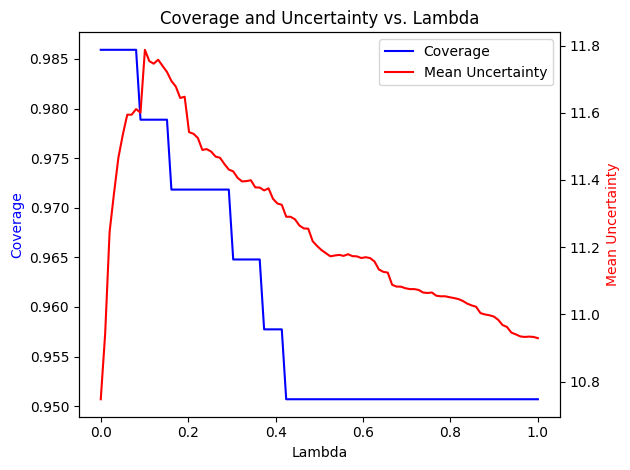

In [ ]:
lambda_list = np.linspace(0, 1, 100)
coverage_list = []
uncertainty_list = []

for lam in lambda_list:
    geosimcp = GeoSIMConformalSpatialRegression(
      predict_f=model_spatial.predict,            # 原模型，含地理特征
      miscoverage_level=0.1,
      bandwidth=3,
      coord_calib=loc_val.values,
      coord_test=loc_test.values,
      X_calib=X_spatial_val,                          # 包含经纬度特征
      y_calib=y_val,
      X_test=X_spatial_test,                          # 包含经纬度特征
      y_test=y_test,
      X_calib_weight=X_aspatial_val,              # 💡 纯特征向量，不含经纬度
      X_test_weight=X_aspatial_test,
      lambda_weight=lam
  )
    result = geosimcp.analyze()
    coverage_list.append(result.coverage_probability)
    uncertainty_list.append(result.uncertainty)


fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(lambda_list, coverage_list, 'b-', label='Coverage')
ax2.plot(lambda_list, uncertainty_list, 'r-', label='Mean Uncertainty')

ax1.set_ylabel('Coverage', color='b')
ax2.set_ylabel('Mean Uncertainty', color='r')
ax1.set_xlabel('Lambda')

# 合并两个 y 轴的图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.title('Coverage and Uncertainty vs. Lambda')
plt.tight_layout()
plt.show()



In [ ]:
X_spatial_val

,dem,sp,tp,blh,r,aod_sat,ndvi,lon,lat
354,211,97037.335938,0.002930,122.335640,74.622887,0.821065,2210,106.513000,29.389000
554,679,91500.070312,0.001168,141.428116,64.168602,0.451809,3066,113.592200,37.856100
439,-5,100785.515625,0.000588,306.366364,55.012974,0.591551,2993,122.215000,40.651100
1030,51,100346.500000,0.000649,259.619354,57.501186,0.722748,2779,115.062800,35.767200
1323,4,101054.234375,0.004096,291.782074,84.106270,0.590020,2462,121.614722,29.901667
...,...,...,...,...,...,...,...,...,...
261,112,99591.101562,0.000955,246.711365,59.567299,0.759752,3422,113.564000,34.802000
427,1066,88599.656250,0.000995,191.095566,30.531921,0.549902,1652,109.810400,40.657500
977,135,96414.437500,0.007347,128.152283,89.964439,0.501047,5843,119.500100,26.694600
904,82,99562.343750,0.000681,179.692978,58.202686,0.383055,1946,130.271900,46.802500


### interval score

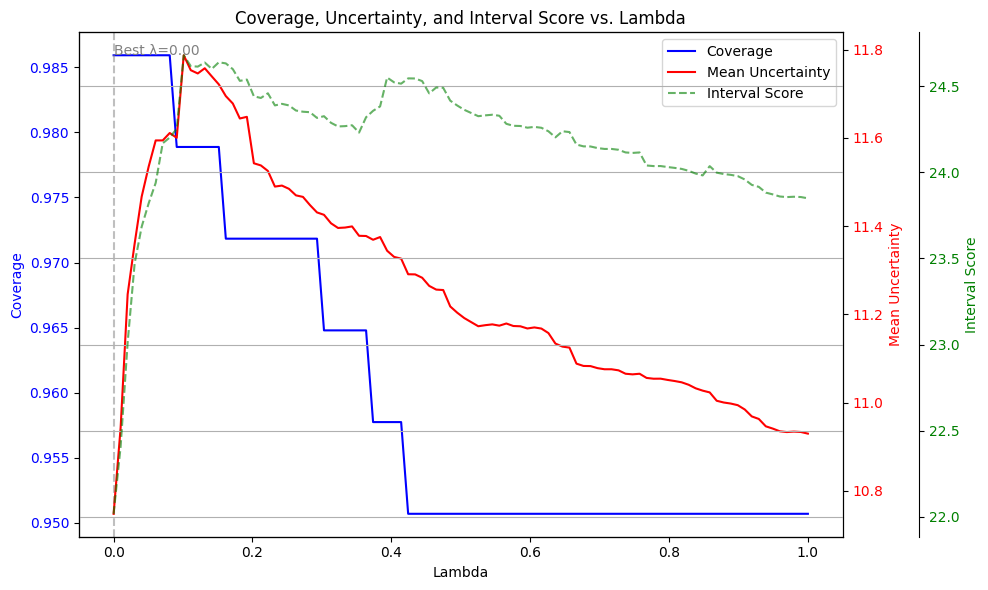

In [ ]:
# 1. 自定义函数
def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)


# 2. 主循环中加入 interval_score 评估
lambda_list = np.linspace(0, 1, 100)
coverage_list = []
uncertainty_list = []
interval_score_list = []

alpha = 0.1

for lam in lambda_list:
    geosimcp = GeoSIMConformalSpatialRegression(
        predict_f=model_spatial.predict,
        miscoverage_level=alpha,
        bandwidth=3,
        coord_calib=loc_val.values,
        coord_test=loc_test.values,
        X_calib=X_spatial_val,
        y_calib=y_val,
        X_test=X_spatial_test,
        y_test=y_test,
        X_calib_weight=X_aspatial_val,
        X_test_weight=X_aspatial_test,
        lambda_weight=lam
    )

    result = geosimcp.analyze()

    coverage_list.append(result.coverage_probability)
    uncertainty_list.append(result.uncertainty)

    lower = np.array(result.lower_bound)
    upper = np.array(result.upper_bound)
    y_true = np.array(y_test)

    score = interval_score(y_true, lower, upper, alpha=alpha)
    interval_score_list.append(np.mean(score))




import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Coverage - 蓝色
ax1.plot(lambda_list, coverage_list, 'b-', label='Coverage')
ax1.set_ylabel('Coverage', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Uncertainty - 红色
ax2 = ax1.twinx()
ax2.plot(lambda_list, uncertainty_list, 'r-', label='Mean Uncertainty')
ax2.set_ylabel('Mean Uncertainty', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Interval Score - 绿色虚线
ax3 = ax1.twinx()
ax3.spines['right'].set_position(("axes", 1.1))
ax3.plot(lambda_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
ax3.set_ylabel('Interval Score', color='g')
ax3.tick_params(axis='y', labelcolor='g')

# 标注最优点（最小 interval score）
best_idx = np.argmin(interval_score_list)
best_lambda = lambda_list[best_idx]
ax1.axvline(x=best_lambda, color='gray', linestyle='--', alpha=0.5)
ax1.text(best_lambda, coverage_list[best_idx], f'Best λ={best_lambda:.2f}', color='gray')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

ax1.set_xlabel('Lambda')
plt.title('Coverage, Uncertainty, and Interval Score vs. Lambda')
plt.grid(True)
plt.tight_layout()
plt.show()


### Optimize Bandwidth

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)


def bandwidth_sweep(
    bandwidth_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    lambda_weight=0.5
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []

    for bw in bandwidth_list:
        model = GeoSIMConformalSpatialRegression(
            predict_f=model_spatial.predict,
            miscoverage_level=alpha,
            bandwidth=bw,
            coord_calib=loc_val.values,
            coord_test=loc_test.values,
            X_calib=X_spatial_val,
            y_calib=y_val,
            X_test=X_spatial_test,
            y_test=y_test,
            X_calib_weight=X_aspatial_val,
            X_test_weight=X_aspatial_test,
            lambda_weight=lambda_weight
        )

        result = model.analyze()

        coverage_list.append(result.coverage_probability)
        uncertainty_list.append(result.uncertainty)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        interval_score_list.append(np.mean(score))

    # 可视化
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(bandwidth_list, coverage_list, 'b-', label='Coverage')
    ax1.set_ylabel('Coverage', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(bandwidth_list, uncertainty_list, 'r-', label='Mean Uncertainty')
    ax2.set_ylabel('Mean Uncertainty', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))
    ax3.plot(bandwidth_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
    ax3.set_ylabel('Interval Score', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    best_idx = np.argmin(interval_score_list)
    best_bw = bandwidth_list[best_idx]
    ax1.axvline(x=best_bw, color='gray', linestyle='--', alpha=0.5)
    ax1.text(best_bw, coverage_list[best_idx], f'Best bw={best_bw:.2f}', color='gray')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

    ax1.set_xlabel('Bandwidth')
    plt.title('Coverage, Uncertainty, and Interval Score vs. Bandwidth')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


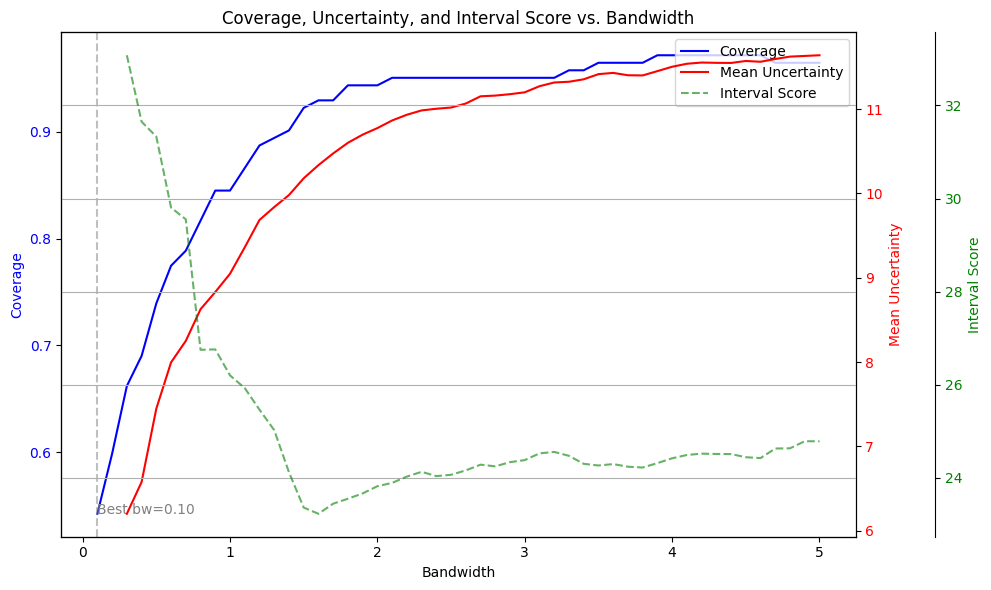

In [ ]:
bandwidth_list = np.linspace(0.1, 5.0, 50)

bandwidth_sweep(
    bandwidth_list=bandwidth_list,
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    lambda_weight=0.5  # 可以固定一个 lambda
)


# GeoSIMCP自动选最优

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from GeoSIMCP import GeoSIMConformalSpatialRegression

# 设置字体以保证 Illustrator 可识别
matplotlib.rcParams['pdf.fonttype'] = 42  # 输出为TrueType
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica']  # 可选: Arial, DejaVu Sans

def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)

def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
    mask = coverage_grid >= threshold
    masked_score = np.where(mask, score_grid, np.inf)
    idx = np.unravel_index(np.argmin(masked_score), masked_score.shape)
    best_lambda = lambda_list[idx[1]]
    best_bandwidth = bandwidth_list[idx[0]]
    return best_lambda, best_bandwidth, masked_score[idx], idx

def bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    pdf_path="grid_sweep_results.pdf"  # 新增参数，指定保存路径
):
    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            model = GeoSIMConformalSpatialRegression(
                predict_f=model_spatial.predict,
                miscoverage_level=alpha,
                bandwidth=bw,
                coord_calib=loc_val.values,
                coord_test=loc_test.values,
                X_calib=X_spatial_val,
                y_calib=y_val,
                X_test=X_spatial_test,
                y_test=y_test,
                X_calib_weight=X_aspatial_val,
                X_test_weight=X_aspatial_test,
                lambda_weight=lam
            )

            result = model.analyze()

            coverage_grid[i, j] = result.coverage_probability
            uncertainty_grid[i, j] = result.uncertainty

            lower = np.array(result.lower_bound)
            upper = np.array(result.upper_bound)
            y_true = np.array(y_test)

            score = interval_score(y_true, lower, upper, alpha=alpha)
            interval_score_grid[i, j] = np.mean(score)

    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]

     # Heatmap 可视化部分
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='YlGnBu',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[0].set_title('Coverage')
    axs[0].set_xlabel('Lambda')
    axs[0].set_ylabel('Bandwidth')
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='YlOrBr',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[1].set_title('Mean Uncertainty')
    axs[1].set_xlabel('Lambda')
    axs[1].set_ylabel('Bandwidth')
    fig.colorbar(im2, ax=axs[1])

    masked_score_grid = np.where(coverage_grid >= coverage_threshold, interval_score_grid, np.nan)
    im3 = axs[2].imshow(masked_score_grid, origin='lower', aspect='auto', cmap='BuGn',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[2].set_title(f'Interval Score (coverage ≥ {coverage_threshold:.2f})')
    axs[2].set_xlabel('Lambda')
    axs[2].set_ylabel('Bandwidth')
    fig.colorbar(im3, ax=axs[2])


    axs[2].scatter([best_lambda], [best_bw], color='black', label='Best (λ, bw)', marker='x')
    axs[2].legend()

    plt.tight_layout()
    plt.savefig(pdf_path, format='pdf')  # 保存为 PDF 矢量图
    plt.close()

    print(f"Best parameters (coverage ≥ {coverage_threshold}):")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Lambda          = {best_lambda:.3f}")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Interval   = {best_uncertainty:.3f}")

    return coverage_grid, uncertainty_grid, interval_score_grid


In [ ]:
%%time
coverage_grid, uncertainty_grid, interval_score_grid = bandwidth_lambda_grid_sweep(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    lambda_list=np.linspace(0, 1.0, 20),
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    pdf_path="PM2.5_GeoSIMCP.pdf"

)


Best parameters (coverage ≥ 0.9):
  Coverage        = 0.986
  Lambda          = 0.000
  Bandwidth       = 2.937
  Interval Score  = 22.009
  Mean Interval   = 10.744
CPU times: user 19.1 s, sys: 207 ms, total: 19.3 s
Wall time: 21.5 s


# GeoSIMCP——zhao2024 自动选最优

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from GeoSIMCPzhao import GeoSIMCPzhao

# 设置 PDF 兼容字体
matplotlib.rcParams['pdf.fonttype'] = 42  # 字体向量化，确保 Illustrator 可识别
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'     # Helvetica/Arial 一般最安全

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    score = np.where(np.isnan(score), 0.0, score)
    return score

def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
    mask = coverage_grid >= threshold
    masked_score = np.where(mask, score_grid, np.inf)
    idx = np.unravel_index(np.argmin(masked_score), masked_score.shape)
    best_lambda = lambda_list[idx[1]]
    best_bandwidth = bandwidth_list[idx[0]]
    return best_lambda, best_bandwidth, masked_score[idx], idx

def bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    output_pdf_path='grid_sweep_results.pdf'  # 新增参数：输出PDF路径
):
    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            model = GeoSIMCPzhao(
                predict_f=model_spatial.predict,
                miscoverage_level=alpha,
                bandwidth=bw,
                coord_calib=loc_val.values,
                coord_test=loc_test.values,
                X_calib=X_spatial_val,
                y_calib=y_val,
                X_test=X_spatial_test,
                y_test=y_test,
                X_calib_weight=X_aspatial_val,
                X_test_weight=X_aspatial_test,
                lambda_weight=lam
            )

            result = model.analyze()

            coverage_grid[i, j] = result.coverage_probability
            if result.geo_uncertainty is not None:
                valid_uncertainty = np.array(result.geo_uncertainty)
                valid_uncertainty = valid_uncertainty[~np.isnan(valid_uncertainty)]
                uncertainty_grid[i, j] = np.mean(valid_uncertainty) if len(valid_uncertainty) > 0 else np.nan
            else:
                uncertainty_grid[i, j] = np.nan

            lower = np.array(result.lower_bound)
            upper = np.array(result.upper_bound)
            y_true = np.array(y_test)

            score = interval_score(y_true, lower, upper, alpha=alpha)
            score_filtered = score[~np.isnan(score)]
            interval_score_grid[i, j] = np.mean(score_filtered) if len(score_filtered) > 0 else np.nan

            if np.isnan(interval_score_grid[i, j]):
                print(f"[Warning] NaN interval score at λ={lam:.3f}, bw={bw:.3f}")

    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='YlGnBu',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[0].set_title('Coverage')
    axs[0].set_xlabel('Lambda')
    axs[0].set_ylabel('Bandwidth')
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='YlOrBr',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[1].set_title('Mean Uncertainty')
    axs[1].set_xlabel('Lambda')
    axs[1].set_ylabel('Bandwidth')
    fig.colorbar(im2, ax=axs[1])

    masked_score_grid = np.where(coverage_grid >= coverage_threshold, interval_score_grid, np.nan)
    im3 = axs[2].imshow(masked_score_grid, origin='lower', aspect='auto', cmap='BuGn',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[2].set_title(f'Interval Score (coverage ≥ {coverage_threshold:.2f})')
    axs[2].set_xlabel('Lambda')
    axs[2].set_ylabel('Bandwidth')
    fig.colorbar(im3, ax=axs[2])

    axs[2].scatter([best_lambda], [best_bw], color='black', label='Best (λ, bw)', marker='x')
    axs[2].legend()

    plt.tight_layout()
    plt.savefig(output_pdf_path, format='pdf')  # 关键导出步骤
    plt.show()

    print(f"Best parameters (coverage ≥ {coverage_threshold}):")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Lambda          = {best_lambda:.3f}")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Interval   = {best_uncertainty:.3f}")

    return coverage_grid, uncertainty_grid, interval_score_grid


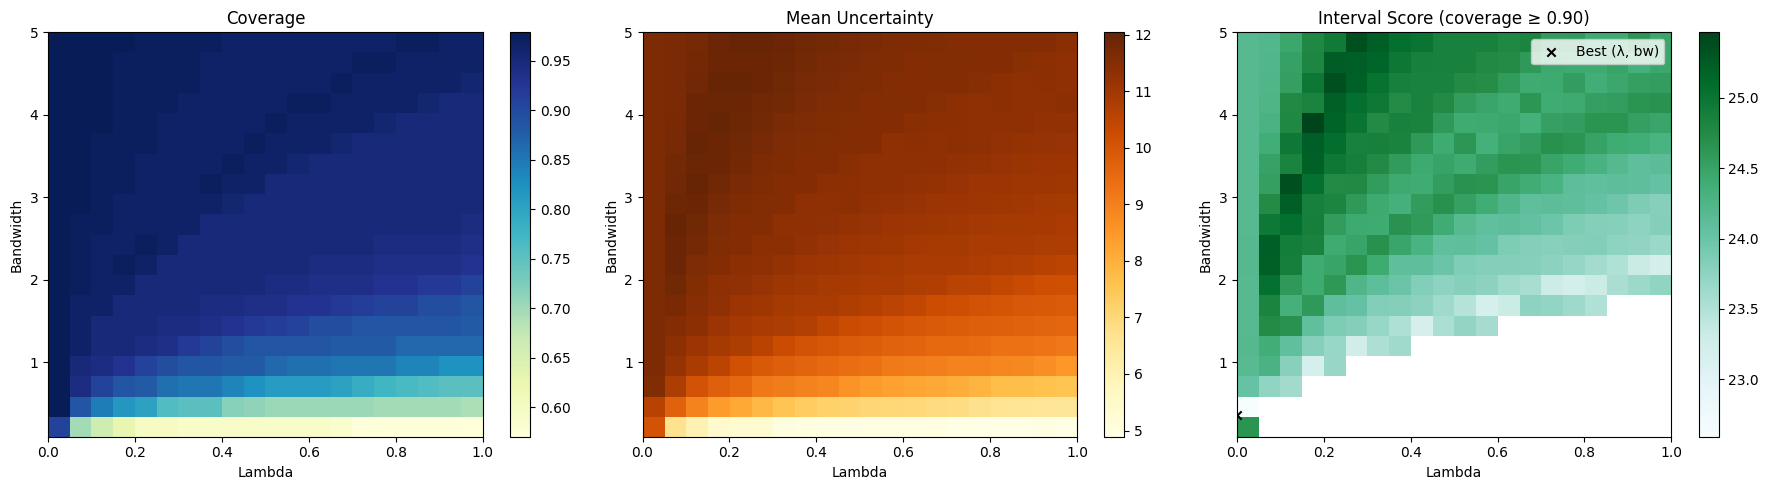

Best parameters (coverage ≥ 0.9):
  Coverage        = 0.979
  Lambda          = 0.000
  Bandwidth       = 0.358
  Interval Score  = 22.592
  Mean Interval   = 10.590
CPU times: user 17 s, sys: 207 ms, total: 17.2 s
Wall time: 13.5 s


In [ ]:
%%time
coverage_grid, uncertainty_grid, interval_score_grid = bandwidth_lambda_grid_sweep(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    lambda_list=np.linspace(0, 1.0, 20),
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    output_pdf_path='PM2.5_GeoSIMCP_zhao.pdf'  # 加这一行即可导出 PDF

)

In [ ]:
coverage_grid

array([[0.9084507 , 0.6971831 , 0.66197183, 0.62676056, 0.59859155,
        0.59859155, 0.5915493 , 0.5915493 , 0.5915493 , 0.5915493 ,
        0.5915493 , 0.5915493 , 0.5915493 , 0.58450704, 0.57042254,
        0.57042254, 0.57042254, 0.57042254, 0.57042254, 0.57042254],
       [0.97887324, 0.88732394, 0.84507042, 0.81690141, 0.8028169 ,
        0.76056338, 0.75352113, 0.75352113, 0.71830986, 0.71126761,
        0.70422535, 0.70422535, 0.70422535, 0.70422535, 0.70422535,
        0.6971831 , 0.6971831 , 0.6971831 , 0.6971831 , 0.69014085],
       [0.97887324, 0.94366197, 0.9084507 , 0.88732394, 0.88028169,
        0.85915493, 0.85211268, 0.85211268, 0.83802817, 0.82394366,
        0.80985915, 0.80985915, 0.80985915, 0.8028169 , 0.78873239,
        0.77464789, 0.76760563, 0.76056338, 0.75352113, 0.75352113],
       [0.97887324, 0.95070423, 0.94366197, 0.92957746, 0.9084507 ,
        0.8943662 , 0.88732394, 0.88732394, 0.88028169, 0.88028169,
        0.86619718, 0.85915493, 0.85915493, 0